In [15]:
##### Import #######

import random
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import copy


from bmg_fun import convert_to_nx
from MISC_Functions import generateGeneTree_maxLeaves
from bmg_Tony import bmg
from all_BCEA import BCEA1 ,BCEA2, BCEA3, BCEA4
from BICcherry_reverse import BICcherry_reverse as BCEA5
from insert_hybrid import insertHybrid
from matplotlib import cm

In [16]:
RUNS = 10000

maxLeaves = 30
hybridRange = (0,8)
speciesRange = (2,10)

countweak = np.zeros((RUNS,5))
countstrict = np.zeros((RUNS,4))

countWeakEdges = 0
countStrictEdges = 0
countWNotS = 0
countSNotW = 0

for run in range(RUNS):
    nHybrids = random.randint(hybridRange[0],hybridRange[1])
    nSpecies = random.randint(speciesRange[0],speciesRange[1])

    _, geneTree = generateGeneTree_maxLeaves(nSpecies= nSpecies, max_leaves= maxLeaves)
    Tree = convert_to_nx(geneTree)
    Tree = insertHybrid(Tree,nHybrids)

    ######## weak section #############
    WBMG = bmg(Tree, mode= 'weak')

    BC1 = BCEA1(WBMG)
    countweak[run][0] = int(nx.utils.graphs_equal(WBMG, bmg(BC1, 'weak')))
    BC2 = BCEA2(WBMG)
    countweak[run][1] = int(nx.utils.graphs_equal(WBMG, bmg(BC2, 'weak')))
    BC3 = BCEA3(WBMG, 'weak')
    countweak[run][2] = int(nx.utils.graphs_equal(WBMG, bmg(BC3, 'weak')))
    BC4 = BCEA4(WBMG)
    countweak[run][3] = int(nx.utils.graphs_equal(WBMG, bmg(BC4, 'weak')))
    BC5 = BCEA5(WBMG, simplify=True)
    countweak[run][4] = int(nx.utils.graphs_equal(WBMG, bmg(BC5, 'weak')))


    ######## strict section #############
    SBMG = bmg(Tree, mode= 'strong')

    BC1 = BCEA1(SBMG)
    countstrict[run][0] = int(nx.utils.graphs_equal(SBMG, bmg(BC1, 'strong')))
    BC2 = BCEA2(SBMG)
    countstrict[run][1] = int(nx.utils.graphs_equal(SBMG, bmg(BC2, 'strong')))
    BC3 = BCEA3(SBMG, 'strong')
    countstrict[run][2] = int(nx.utils.graphs_equal(SBMG, bmg(BC3, 'strong')))
    BC4 = BCEA5(SBMG, simplify=True)
    countstrict[run][3] = int(nx.utils.graphs_equal(SBMG, bmg(BC4, 'strong')))


    for (node1w,node2w) in WBMG.edges:
        countWeakEdges += 1
        if not SBMG.has_edge(node1w,node2w):
            countWNotS += 1


    for (node1s,node2s) in SBMG.edges:
        countStrictEdges += 1
        if not WBMG.has_edge(node1s,node2s):
            countSNotW += 1

c:\Users\tony\GitHub\fortgeschrittene_Methoden_der_Bioinformatik\Code\BICcherry_reverse.py:301: UserWarning: BICcherry_reverse: could not place edges [('13', '4'), ('14', '4'), ('15', '4'), ('16', '4'), ('17', '4'), ('6', '17'), ('8', '17'), ('9', '17')]
  warnings.warn(f"BICcherry_reverse: could not place edges {pending}")
c:\Users\tony\GitHub\fortgeschrittene_Methoden_der_Bioinformatik\Code\BICcherry_reverse.py:301: UserWarning: BICcherry_reverse: could not place edges [('24', '39'), ('25', '39'), ('27', '39'), ('33', '39'), ('34', '39'), ('35', '39')]
  warnings.warn(f"BICcherry_reverse: could not place edges {pending}")
c:\Users\tony\GitHub\fortgeschrittene_Methoden_der_Bioinformatik\Code\BICcherry_reverse.py:301: UserWarning: BICcherry_reverse: could not place edges [('11', '8')]
  warnings.warn(f"BICcherry_reverse: could not place edges {pending}")
c:\Users\tony\GitHub\fortgeschrittene_Methoden_der_Bioinformatik\Code\BICcherry_reverse.py:301: UserWarning: BICcherry_reverse: could

In [17]:
print(f"Die {RUNS} generierten Bäume haben nach der strikten Definition insgesamt {countWeakEdges} best matches")
print(f"Von diesen {countWeakEdges} gibt es {countWNotS} weak best matches, die keine strict best matches sind. Das entspricht einem Anteil von {round(countWNotS/countWeakEdges*100,3)}%")
print(f"Es gibt insgesamt {countStrictEdges} strict best matches")
print(f"Es gibt in allen Bäumen genau {countSNotW} strong best matches, die keine weak best matches sind")

Die 10000 generierten Bäume haben nach der strikten Definition insgesamt 1421849 best matches
Von diesen 1421849 gibt es 10869 weak best matches, die keine strict best matches sind. Das entspricht einem Anteil von 0.764%
Es gibt insgesamt 1410980 strict best matches
Es gibt in allen Bäumen genau 0 strong best matches, die keine weak best matches sind


([<matplotlib.patches.Wedge at 0x2d688076210>,
 [Text(-1.099687609585227, 0.02621376212468086, 'strict best matches'),
  Text(1.0996876181266966, -0.026213403800974176, 'weak best matches')],
 [Text(-0.5998296052283056, 0.014298415704371377, '99.2%'),
  Text(0.599829609887289, -0.014298220255076821, '0.8%')])

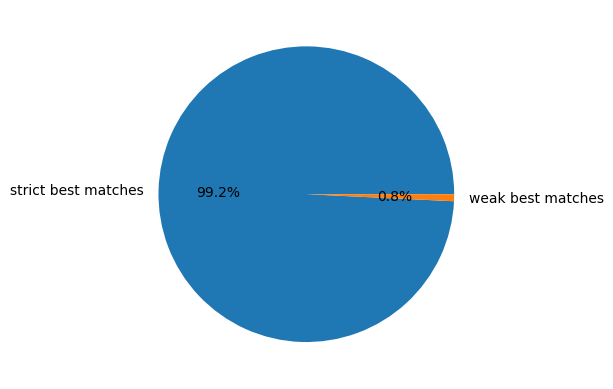

In [18]:
labels = 'strict best matches', 'weak best matches'
sizes = [(countWeakEdges/(countWeakEdges+countWNotS)), (countWNotS/(countWeakEdges+countWNotS))]

fig, ax = plt.subplots()
ax.pie(sizes, labels=labels, autopct='%1.1f%%')

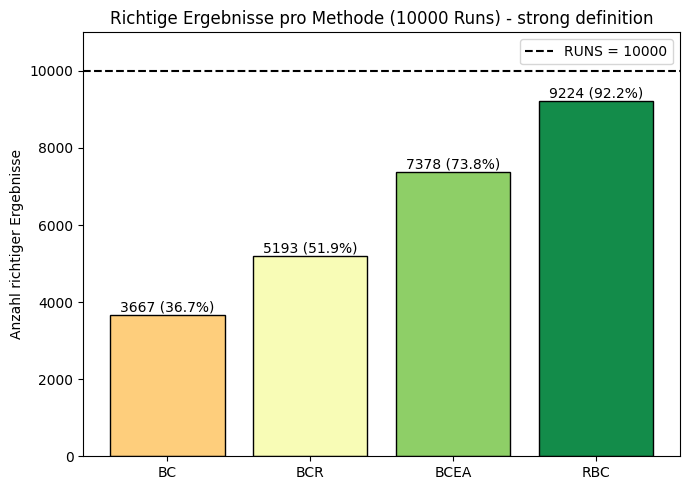

In [19]:
##################################
############## Plot ##############
##################################
MODE = 'strong'
bars = 4

if MODE == 'weak':
    if bars > 5:
        raise ValueError("so viele Modelle gibt es nicht")
    labels = ['BC', 'BCR', 'BCRS', 'MLBCEA', 'RBC']
    labels = labels[:(bars)]
    werte = np.sum(countweak, axis=0)
    werte = werte[:(bars)]



if MODE =='strong':
    if bars > 4:
        raise ValueError("so viele Modelle gibt es nicht")
    labels = ['BC', 'BCR', 'BCEA', 'RBC']
    labels = labels[:(bars)]
    werte = np.sum(countstrict, axis=0)
    werte = werte[:(bars)]

# Farbgradient: 0% = rot, 100% = grün
cmap = plt.get_cmap('RdYlGn')   # rot -> gelb -> grün
farben = cmap(werte / RUNS)

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(labels, werte, color=farben, edgecolor='black')

# Horizontale Linie bei y = RUNS
ax.axhline(RUNS, color='black', linestyle='--', linewidth=1.5, label=f'RUNS = {RUNS}')

# Werte über den Balken anzeigen
for bar, w in zip(bars, werte):
    ax.text(bar.get_x() + bar.get_width() / 2, w + 10,
            f'{int(w)} ({w / RUNS:.1%})', ha='center', va='bottom')

ax.set_title(f'Richtige Ergebnisse pro Methode ({RUNS} Runs) - {MODE} definition')
ax.set_ylabel('Anzahl richtiger Ergebnisse')
ax.set_ylim(0, RUNS * 1.1)
ax.legend()

sm = cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, 100))

plt.tight_layout()
plt.show()
